In [103]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re
from transformers import pipeline

In [110]:
# Define Emotion <-> Labeling relation (standard) 
emotion_to_label = {
    'sadness': 0,
    'joy': 1,
    'love': 2,
    'anger': 3,
    'fear': 4,
    'surprise': 5
}

def check_imbalances(df: pd.DataFrame, group_column: str) -> list:
    group_counts = df[group_column].value_counts(dropna=False)
    total = len(df)
    group_percent = group_counts / total * 100
    result = pd.DataFrame({
        'group': group_counts.index,
        'count': group_counts.values,
        'percentage': group_percent.round(2).values
    })
    return result

def find_special_characters(df: pd.DataFrame, column_to_check: str) -> set:
    all_text = ' '.join(df['text'].astype(str))
    special_chars = set(re.findall(r'[^A-Za-z0-9\s]', all_text))
    return special_chars

def assign_label(df: pd.DataFrame, emotion_to_label: dict) -> pd.DataFrame:    
    df['label_ml'] = df.apply(lambda row: emotion_to_label[row['emotion']], axis=1)
    return df

def extract_labels(df):
    classifier = pipeline("text-classification",model='bhadresh-savani/distilbert-base-uncased-emotion', return_all_scores=True)
    def get_label(text):
        scores = classifier(text)  
        return scores[0]['label']
    
    df['emotion_ml'] = df['text'].apply(get_label)
    return df

def get_generated_text(text, prompt):
    text = text.replace(prompt, '').strip()
    sentences = [s.strip() for s in re.split(r'[.!?]|\n\n', text) if s.strip()]
    return ' '.join(sentences)

def generate_emotion_sentences(generator, emotion, num_rows):
    prompt = f"Write a short sentence that expresses {emotion}:"
    texts = []
    for _ in range(num_rows):
        results = generator(
            prompt,
            max_new_tokens=32,
            do_sample=True,
            top_k=50,
            top_p=0.95,
            pad_token_id=50256
        )
        generated = get_generated_text(results[0]['generated_text'], prompt)
        if generated and generated not in texts:
            texts.append(generated)
    df = pd.DataFrame({
        'text': texts,
        'label': [emotion_to_label[emotion]] * len(texts),
        'emotion': [emotion] * len(texts)
    })
    return df

In [126]:
hometask_df = pd.read_csv('hometask_dataset.csv')
hometask_df.head(5)

,text,label,emotion
0,i didnt feel humiliated,0.0,sadness
1,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,NaN,sadness
2,im grabbing a minute to post i feel greedy wrong,3.0,anger
3,i am ever feeling nostalgic about the fireplace i will know that it is still on the property,2.0,love
4,i am feeling grouchy,3.0,anger


# Investigave Data Issues

## Check Duplicates

In [127]:
hometask_df[hometask_df.duplicated(subset=['text'])]

,text,label,emotion


## Check Imbalances

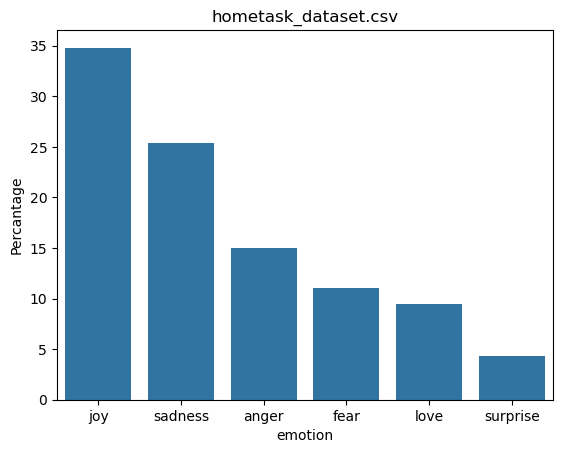

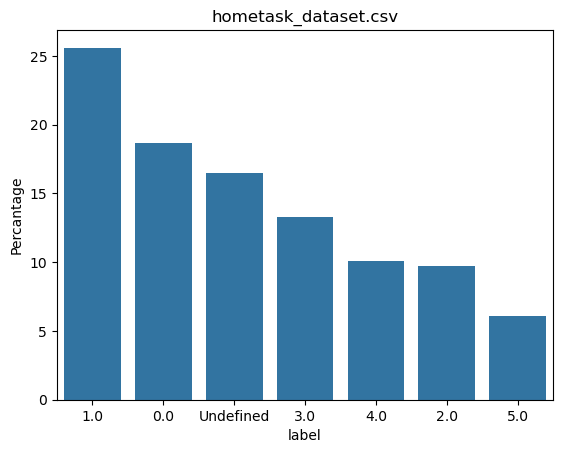

In [128]:
emotions = check_imbalances(hometask_df, 'emotion')
sns.barplot(x='group', y='percentage', data=emotions)
plt.xlabel('emotion')
plt.ylabel('Percantage')
plt.title('hometask_dataset.csv')
plt.show()

labels = check_imbalances(hometask_df, 'label')
labels['group'] = np.where(pd.isna(labels['group']), 'Undefined', labels['group'])
sns.barplot(x='group', y='percentage', data=labels)
plt.xlabel('label')
plt.ylabel('Percantage')
plt.title('hometask_dataset.csv')
plt.show()

## Check Completeness

In [129]:
print(f"Missing 'text' count: {len(hometask_df[pd.isna(hometask_df['text'])])}")
print(f"Missing 'labels' count: {len(hometask_df[pd.isna(hometask_df['label'])])}")
print(f"Missing 'emotion' count: {len(hometask_df[pd.isna(hometask_df['emotion'])])}")

Missing 'text' count: 0
Missing 'labels' count: 165
Missing 'emotion' count: 0


## Check Special Characters

In [130]:
spec_chars = find_special_characters(hometask_df, 'text')
print("Needs to be removed the following symbols:")
print(spec_chars)

Needs to be removed the following symbols:
{']', '~', '<', '!', '(', ':', '\\', ')', '_', '-', '|', '{', '.', '}', '?', '"', "'", ';', '/'}


## Find Incorrect Labeling

In [131]:
hometask_df = assign_label(hometask_df, emotion_to_label)
hometask_df[hometask_df['label'] != hometask_df['label_ml']]

,text,label,emotion,label_ml
1,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,NaN,sadness,0
5,ive been feeling a little burdened lately wasnt sure why that was,NaN,sadness,0
6,ive been taking or milligrams or times recommended amount and ive fallen asleep a lot faster but i also feel like so funny,4.0,surprise,5
8,i have been with petronas for years i feel that petronas has performed well and made a huge profit,NaN,joy,1
9,i feel romantic too,0.0,love,2
14,i have immense sympathy with the general point but as a possible proto writer trying to find time to write in the corners of life and with no sign of an agent let alone a publishing contract this feels a little precious,NaN,joy,1
18,i started feeling sentimental about dolls i had as a child and so began( a collection of vintage barbie dolls from the sixties,3.0,sadness,0
23,i was able to help chai lifeline with your support and encouragement is a great feeling and i am so glad you were able to help me,4.0,joy,1
27,i Become oVERwhELMEd aNd feEl DEFEaTED,1.0,sadness,0
30,i get giddy over feeling elegant in a perfectly fitted pencil skirt,5.0,joy,1


## Find Imcorrect Emotions

In [132]:
# model='bhadresh-savani/distilbert-base-uncased-emotion' is used to verify if the labels are correct
# model will classify the same text column and difference will be displayed

hometask_df = extract_labels(hometask_df)
hometask_df[hometask_df['emotion'] != hometask_df['emotion_ml']]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

,text,label,emotion,label_ml,emotion_ml
43,i feel very strongly passionate about when some jerk off decides to poke and make fun of us,1.0,joy,1,love
129,i too feel as if i am a stranger in a strange land and i am raising my son in a place that is not his father s ancestral home,5.0,surprise,5,fear
248,i feel like i ve been neglecting my beloved mom blog,1.0,joy,1,love
303,fea;r of thief,1.0,fear,4,anger
364,i tend to stop breathing when i m feeling stressed,0.0,sadness,0,anger
386,i feel energized and curiou|s again about life about god about my potential to give something back to society and about finding someone after my heart,5.0,surprise,5,joy
543,i saw the video of cena kissing maria and surprisingly i didnt feel like i hated her,0.0,sadness,0,anger
556,i feel completely ble?ssed to be a part of this group,1.0,love,2,joy
566,i was feeling imp(atient and took pills,1.0,anger,3,joy
583,i feel hated loathed,NaN,sadness,0,anger


# Correct Data Issues

The following needs to be corrected:

1) *Imbalances*: data needs to be balanced across emotions; Right now it's Imbalanced.

To balance groups the following needs to be generated:
+ joy: 340 (already has 340, so need 0)
+ sadness: 250 → need 90 more
+ anger: 140 → need 200 more
+ fear: 120 → need 220 more
+ love: 90 → need 250 more
+ surprise: 60 → need 280 more

2) *Special Characters Removal and Lower Casing*
3) *Incorrect Emotions (based on 'bhadresh-savani/distilbert-base-uncased-emotion' model)*
4) *Incorrect Labels (based on industry standarts)*

In [97]:
hometask_df['text'] = hometask_df['text'].apply(lambda x: re.sub(r'[\/\-\]\{\\"<\}\|\.\\_!:\(\);\?~\'"]', "", x).lower())

# check removal
spec_chars = find_special_characters(hometask_df, 'text')
print("Needs to be removed the following symbols:")
print(spec_chars)

Needs to be removed the following symbols:
set()


## Fix Imbalances

### Generate Synthetic Data

In [113]:
generator = pipeline("text-generation", model="gpt2")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [114]:
sadness_df = generate_emotion_sentences(generator, 'sadness', num_rows=100)
sadness_df.head(5)

Both `max_new_tokens` (=32) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=32) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=32) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=32) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

,text,label,emotion
0,"""What did you do "" and then make a small gesture of sadness and then make an exaggerated gesture of sadness You can also take a short sentence and say",0,sadness
1,"""I think that the country needs to take a look at the situation and do something to help the people in our country "" We've seen",0,sadness
2,"""Oh, I was hoping that he'd let me get away with that "" Take a long sentence that expresses regret: ""He never even called me",0,sadness
3,"""I'm sorry for my loss I couldn't be here to help "" ""I'm sorry for your loss,"" she says ""I'm",0,sadness
4,"""I'm sorry, I'm sorry "" In the short sentence, ""I'm sorry, I'm sorry"" is a simple, succinct, yet",0,sadness


In [115]:
anger_df = generate_emotion_sentences(generator, 'anger', num_rows=200)
anger_df.head(5)

Both `max_new_tokens` (=32) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=32) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=32) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=32) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

,text,label,emotion
0,'I am a bad person ' 'I am a bad person ' 'I am a racist ' 'I am a bigot ' 'I am a,3,anger
1,"""I want you to give me a hand I want you to let me make a change "" This means that if you write the sentence, you",3,anger
2,"""I am just going to say it "" Use a long one: ""I am just going to say it "" Don't make a direct statement:",3,anger
3,"""I'm a man who can't be a man"" ""I'm a man who's a woman who can't be a man""",3,anger
4,"""I'm sorry, but I've been in an angry state "" In the words of a friend, ""The only thing you can do is say",3,anger


In [116]:
fear_df = generate_emotion_sentences(generator, 'fear', num_rows=220)
fear_df.head(5)

Both `max_new_tokens` (=32) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=32) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=32) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=32) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

,text,label,emotion
0,"""We're going to take a deep breath, we're going to take a deep breath We're going to take a deep breath """,4,fear
1,I've never seen anything like it And that's what I did And that's what I did I think,4,fear
2,"""I'm afraid I'm going to die, and I'm afraid I'm going to die "" If you don't have a fear of",4,fear
3,"""The American people have finally seen the end of the Cold War The United States of America has been liberated from the cold war that was caused by",4,fear
4,"In a few days, your family will be able to hear that your wife is dead In a few days, your family will be able",4,fear


In [117]:
love_df = generate_emotion_sentences(generator, 'love', num_rows=250)
love_df.head(5)

Both `max_new_tokens` (=32) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=32) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=32) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=32) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

,text,label,emotion
0,"""A loving thing you do to someone who is so horrible you don't even know what you're doing "" You can also choose to say, ""I love",2,love
1,"""I love you so much, it hurts me to say it but I love you too much to say it "" I love you so much",2,love
2,"""It's a great feeling to be in love "" I'll probably get the full sentence The next day, we were sitting in my",2,love
3,"Love is a thing, it's all about us The more you love, the more you can love Love is the one thing in",2,love
4,"This is a love letter to your future, and you've gotten it I'm sure you're happy with it, and you are proud",2,love


In [118]:
surprise_df = generate_emotion_sentences(generator, 'surprise', num_rows=280)
surprise_df.head(5)

Both `max_new_tokens` (=32) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=32) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=32) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=32) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

,text,label,emotion
0,"""I think you were born in the United States and you are going to be born here "" It's a common tactic by the government, and a",5,surprise
1,"""I didn't know what to do with this "" And then there's the moment when he's so happy that he's actually able to see himself",5,surprise
2,"""The reason why I'm not using it is that I don't know what the word 'excuse' means, and I'm not sure where",5,surprise
3,What's the big deal about the new law It's that it has to be done so that the people who are being targeted are actually looking for,5,surprise
4,"This was a real, real surprise I wanted to get to know the person in the story It's a good question",5,surprise


In [121]:
synthetic_data = [sadness_df, anger_df, fear_df, love_df, surprise_df]
synthetic_df = pd.concat(synthetic_data, ignore_index=True)
synthetic_df.head(5)

,text,label,emotion
0,"""What did you do "" and then make a small gesture of sadness and then make an exaggerated gesture of sadness You can also take a short sentence and say",0,sadness
1,"""I think that the country needs to take a look at the situation and do something to help the people in our country "" We've seen",0,sadness
2,"""Oh, I was hoping that he'd let me get away with that "" Take a long sentence that expresses regret: ""He never even called me",0,sadness
3,"""I'm sorry for my loss I couldn't be here to help "" ""I'm sorry for your loss,"" she says ""I'm",0,sadness
4,"""I'm sorry, I'm sorry "" In the short sentence, ""I'm sorry, I'm sorry"" is a simple, succinct, yet",0,sadness


### Normalize Synthetic Data

In [123]:
# update regular expession in case returned special characters after check and re-run this command again
synthetic_df['text'] = synthetic_df['text'].apply(lambda x: re.sub(r'[\/\-\]\[*\{\\"<>#=\}\|\.\,\…\—\\_!:\(\);\?~\'"]', "", x).lower())

# check removal
spec_chars_synth = find_special_characters(synthetic_df, 'text')
print("Needs to be removed the following symbols:")
print(spec_chars_synth)

Needs to be removed the following symbols:
set()


## Remove Special Characters And Normalize

In [133]:
hometask_df['text'] = hometask_df['text'].apply(lambda x: re.sub(r'[\/\-\]\{\\"<\}\|\.\\_!:\(\);\?~\'"]', "", x).lower())

# check removal
spec_chars = find_special_characters(hometask_df, 'text')
print("Needs to be removed the following symbols:")
print(spec_chars)

Needs to be removed the following symbols:
set()


## Fix Incorrect Emotions

In [134]:
# Incorrect Emotions is fixed with accepting model='bhadresh-savani/distilbert-base-uncased-emotion' generated values 

hometask_df['emotion'] = np.where(hometask_df['emotion'] != hometask_df['emotion_ml'], hometask_df['emotion_ml'], hometask_df['emotion'])
hometask_df.drop('emotion_ml', axis=1, inplace=True)
hometask_df.head(5)

,text,label,emotion,label_ml
0,i didnt feel humiliated,0.0,sadness,0
1,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,NaN,sadness,0
2,im grabbing a minute to post i feel greedy wrong,3.0,anger,3
3,i am ever feeling nostalgic about the fireplace i will know that it is still on the property,2.0,love,2
4,i am feeling grouchy,3.0,anger,3


## Fix Incorrect Labeling

In [135]:
# Labeling is fixing with values replacement for industry standard values  

hometask_df['label'] = np.where(hometask_df['label'] != hometask_df['label_ml'], hometask_df['label_ml'], hometask_df['label'])
hometask_df.drop('label_ml', axis=1, inplace=True)
hometask_df.head(5)

,text,label,emotion
0,i didnt feel humiliated,0.0,sadness
1,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,0.0,sadness
2,im grabbing a minute to post i feel greedy wrong,3.0,anger
3,i am ever feeling nostalgic about the fireplace i will know that it is still on the property,2.0,love
4,i am feeling grouchy,3.0,anger


# Combine Original Dataset With Synthetic One

In [136]:
hometask_synthetic_data = [synthetic_df, hometask_df]
hometask_synt_df = pd.concat(hometask_synthetic_data, ignore_index=True)
hometask_synt_df.head(5)

,text,label,emotion
0,what did you do and then make a small gesture of sadness and then make an exaggerated gesture of sadness you can also take a short sentence and say,0.0,sadness
1,i think that the country needs to take a look at the situation and do something to help the people in our country weve seen,0.0,sadness
2,oh i was hoping that hed let me get away with that take a long sentence that expresses regret he never even called me,0.0,sadness
3,im sorry for my loss i couldnt be here to help im sorry for your loss she says im,0.0,sadness
4,im sorry im sorry in the short sentence im sorry im sorry is a simple succinct yet,0.0,sadness


## Verify Imbalance

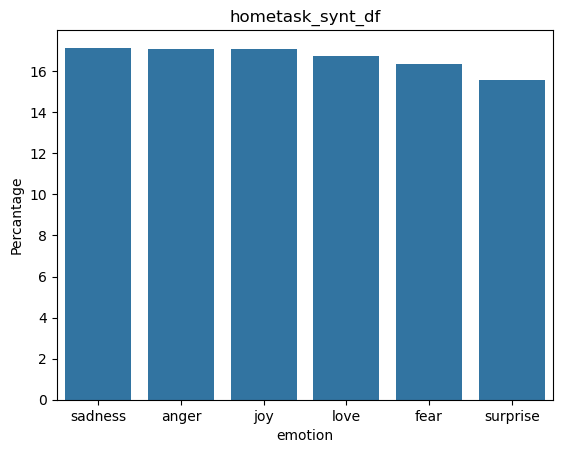

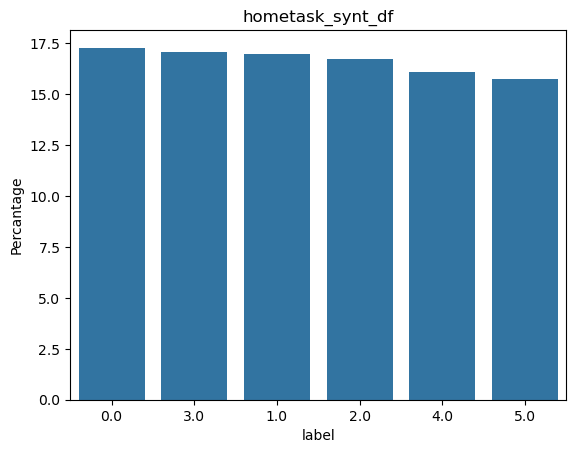

In [137]:
emotions = check_imbalances(hometask_synt_df, 'emotion')
sns.barplot(x='group', y='percentage', data=emotions)
plt.xlabel('emotion')
plt.ylabel('Percantage')
plt.title('hometask_synt_df')
plt.show()

labels = check_imbalances(hometask_synt_df, 'label')
labels['group'] = np.where(pd.isna(labels['group']), 'Undefined', labels['group'])
sns.barplot(x='group', y='percentage', data=labels)
plt.xlabel('label')
plt.ylabel('Percantage')
plt.title('hometask_synt_df')
plt.show()

In [138]:
hometask_synt_df['label'] = hometask_synt_df['label'].astype(int)
hometask_synt_df.to_csv('output_new.csv')